In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report
)

In [2]:

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Dataset shape:", df.shape)
print("\nTarget classes:")
print(pd.Series(data.target_names))

print("\nClass distribution:")
print(df["target"].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sum())

Dataset shape: (569, 31)

Target classes:
0    malignant
1       benign
dtype: object

Class distribution:
1    357
0    212
Name: target, dtype: int64

Missing values:
0


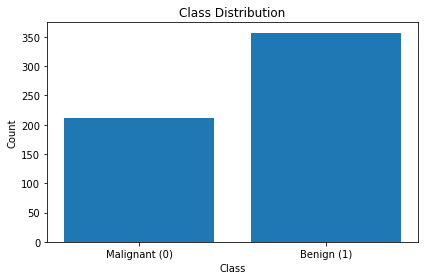

In [4]:
class_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Malignant (0)", "Benign (1)"], class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

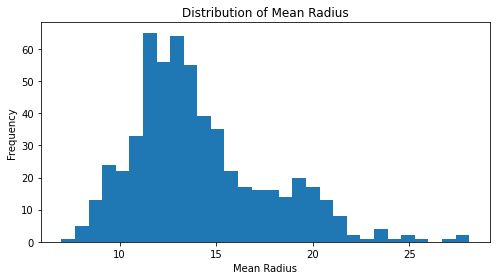

In [5]:
plt.figure(figsize=(7, 4))
plt.hist(df["mean radius"], bins=30)
plt.title("Distribution of Mean Radius")
plt.xlabel("Mean Radius")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

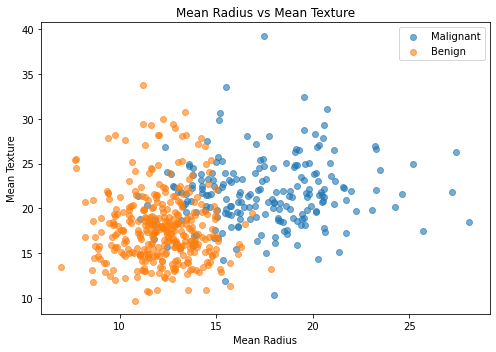

In [6]:
plt.figure(figsize=(7, 5))

malignant = df[df["target"] == 0]
benign = df[df["target"] == 1]

plt.scatter(malignant["mean radius"], malignant["mean texture"], alpha=0.6, label="Malignant")
plt.scatter(benign["mean radius"], benign["mean texture"], alpha=0.6, label="Benign")

plt.title("Mean Radius vs Mean Texture")
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (455, 30)
Testing set shape: (114, 30)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=10000)

In [10]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC-AUC  :", round(auc, 4))

Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-score : 0.9861
ROC-AUC  : 0.9954


In [12]:
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



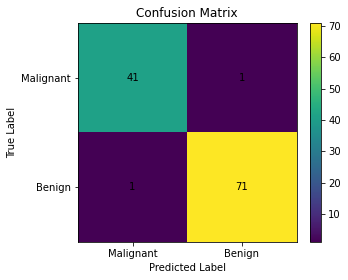

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Malignant", "Benign"])
plt.yticks(tick_marks, ["Malignant", "Benign"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

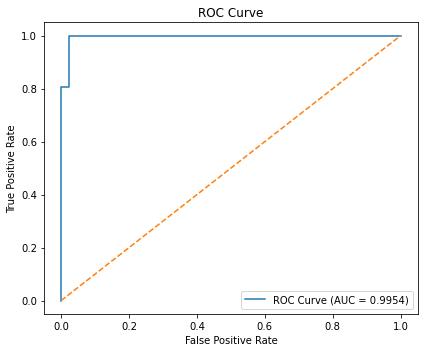

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["AbsoluteCoefficient"] = coefficients["Coefficient"].abs()
top_features = coefficients.sort_values("AbsoluteCoefficient", ascending=False).head(10)

top_features

,Feature,Coefficient,AbsoluteCoefficient
21,worst texture,-1.248332,1.248332
10,radius error,-1.084279,1.084279
23,worst area,-0.953706,0.953706
27,worst concave points,-0.948458,0.948458
20,worst radius,-0.945125,0.945125
28,worst symmetry,-0.935219,0.935219
13,area error,-0.934894,0.934894
26,worst concavity,-0.828861,0.828861
22,worst perimeter,-0.761424,0.761424
24,worst smoothness,-0.752978,0.752978


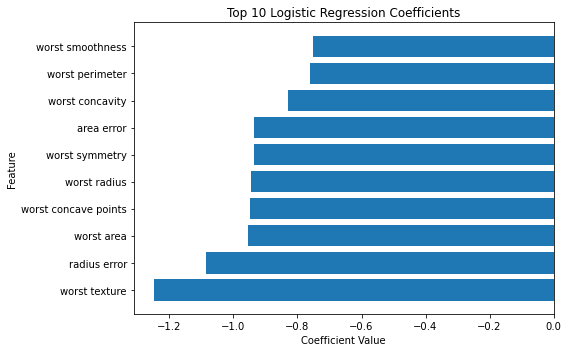

In [16]:
plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Top 10 Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()